## Spectral Leakage & SNR Analysis
Compare Rectangular, Hamming, Hanning windows on a 30 ms speech frame

### 1. Imports & Load

In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

file = "data/heisenberg.mp3"

sig, sr = sf.read(file)

if len(sig.shape) > 1:
    sig = sig.mean(axis=1)

# 30 ms frame starting at 100 ms
start  = int(0.1 * sr)
length = int(0.03 * sr)

frame = sig[start : start + length].astype(np.float64)

print("Frame length (samples):", len(frame))

Frame length (samples): 960


### 2. Three Windows

In [2]:
N = len(frame)

rect    = np.ones(N)
hamming = np.hamming(N)
hanning = np.hanning(N)

windows = {
    "Rectangular": rect,
    "Hamming":     hamming,
    "Hanning":     hanning
}

### 3. FFT → Power (dB)

In [3]:
NFFT = 2048

def get_spectrum(x, win):
    xw  = x * win
    mag = np.abs(np.fft.rfft(xw, NFFT))
    mag = mag / (np.max(mag) + 1e-12)
    pdb = 20 * np.log10(mag + 1e-12)
    return pdb, mag

### 4. Spectral Leakage
Ratio of energy outside the main lobe to total energy — lower is better

In [4]:
def calc_leakage(pdb, peak_idx):
    mag_lin = 10 ** (pdb / 20)
    total   = np.sum(mag_lin ** 2)

    left  = max(0, peak_idx - 5)
    right = min(len(mag_lin), peak_idx + 5 + 1)

    main    = np.sum(mag_lin[left:right] ** 2)
    leakage = (total - main) / (total + 1e-10)
    return leakage

### 5. SNR (dB)
Peak power minus 10th percentile noise floor

In [5]:
def calc_snr(x, win):
    xw  = x * win
    mag = np.abs(np.fft.rfft(xw, NFFT)) + 1e-10
    pdb = 20 * np.log10(mag)
    return float(np.max(pdb) - np.percentile(pdb, 10))

### 6. Main Lobe Width (−3 dB bandwidth in bins)

In [6]:
def main_lobe_width(pdb, peak_idx):
    threshold = pdb[peak_idx] - 3.0
    l = peak_idx
    r = peak_idx
    while l > 0 and pdb[l] >= threshold:
        l -= 1
    while r < len(pdb) - 1 and pdb[r] >= threshold:
        r += 1
    return r - l

### 7. Results Table

In [7]:
results = []
spectra = {}

for name, win in windows.items():
    pdb, _ = get_spectrum(frame, win)
    peak   = int(np.argmax(pdb))
    leak   = calc_leakage(pdb, peak)
    snr    = calc_snr(frame, win)
    width  = main_lobe_width(pdb, peak)
    results.append([name, round(leak, 4), round(snr, 2), width])
    spectra[name] = pdb

print(f"{'Window':<14}  {'Leakage':>9}  {'SNR (dB)':>9}  {'MainLobe (bins)':>16}")
print("-" * 56)
for r in results:
    print(f"{r[0]:<14}  {r[1]:>9.4f}  {r[2]:>9.2f}  {r[3]:>16}")

Window            Leakage   SNR (dB)   MainLobe (bins)
--------------------------------------------------------
Rectangular        0.3866      52.91                 7
Hamming            0.4352      66.46                11
Hanning            0.4529      73.25                16


### 8. Plots

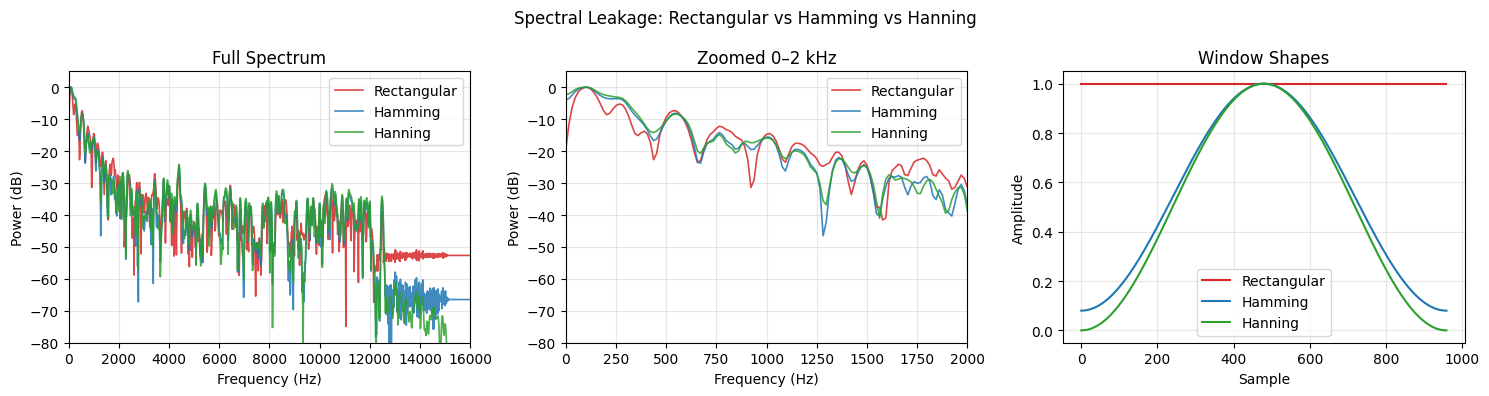

In [8]:
freqs  = np.fft.rfftfreq(NFFT, 1.0 / sr)
colors = {"Rectangular": "tab:red", "Hamming": "tab:blue", "Hanning": "tab:green"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name, pdb in spectra.items():
    axes[0].plot(freqs, pdb, label=name, color=colors[name], lw=1.2, alpha=0.85)
axes[0].set(title="Full Spectrum", xlabel="Frequency (Hz)", ylabel="Power (dB)",
            xlim=[0, sr/2], ylim=[-80, 5])
axes[0].legend(); axes[0].grid(alpha=0.3)

for name, pdb in spectra.items():
    axes[1].plot(freqs, pdb, label=name, color=colors[name], lw=1.2, alpha=0.85)
axes[1].set(title="Zoomed 0–2 kHz", xlabel="Frequency (Hz)", ylabel="Power (dB)",
            xlim=[0, 2000], ylim=[-80, 5])
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(rect,    label="Rectangular", color=colors["Rectangular"], lw=1.5)
axes[2].plot(hamming, label="Hamming",     color=colors["Hamming"],     lw=1.5)
axes[2].plot(hanning, label="Hanning",     color=colors["Hanning"],     lw=1.5)
axes[2].set(title="Window Shapes", xlabel="Sample", ylabel="Amplitude")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Spectral Leakage: Rectangular vs Hamming vs Hanning", fontsize=12)
plt.tight_layout()
plt.savefig("leakage_plot.png", dpi=150)
plt.show()